# H-PPO 主训练入口

该笔记本将逐步整合环境、算法与配置，完成 torchrl + gymnasium 的 H-PPO 训练流程。

In [1]:
from dataclasses import replace
from pathlib import Path
from typing import Dict

import torch
import yaml
from loguru import logger

# import algo.hppo as _hppo_module
# import env.mac_simulator as _mac_module
# import env.satellite_mac_env as _sat_env_module

# reload(_hppo_module)
# reload(_mac_module)
# reload(_sat_env_module)

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    with_delta_mask_info,
 )
from torchrl.envs import ParallelEnv, SerialEnv, TransformedEnv
from torchrl.envs.libs.gym import GymWrapper
from torchrl.envs.transforms import Compose, DoubleToFloat

In [2]:
CONFIG_PATH = Path("conf/default.yaml")
def _load_yaml_config(path: Path) -> Dict:
    if path.exists():
        with path.open("r", encoding="utf-8") as handle:
            data = yaml.safe_load(handle) or {}
            logger.info(f"Loaded configuration from {path}")
            return data
    logger.warning(f"Configuration file {path} not found, using defaults.")
    return {}
raw_config = _load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251106))
torch.manual_seed(seed)
log_section = raw_config.get("logging", {})
log_file = log_section.get("file", "logs/notebook_training.log")
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized (level={log_level}, file={log_file or '<stderr>'})")
env_section = raw_config.get("environment", {})
algo_section = raw_config.get("algorithm", {})
def _override_sim_config(overrides: Dict) -> MACSimulatorConfig:
    base_config = default_simulator_config()
    total = overrides.get("total_preambles")
    split = overrides.get("base_preamble_split")
    if total is not None:
        base_config = replace(base_config, total_preambles=int(total))
    if split is not None:
        if len(split) != 3:
            raise ValueError("base_preamble_split must contain three integers")
        base_config = replace(
            base_config,
            base_preamble_split=tuple(int(x) for x in split),
        )
    return base_config
simulator_config = _override_sim_config(env_section)

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=int(env_section.get("num_slots_per_step", 160)),
    decision_horizon=int(env_section.get("decision_horizon", 256)),
    history_len=int(env_section.get("history_len", 8)),
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
 )
my_logger.info(f'env_config {env_config}')

num_envs = 8 # max(1, int(env_section.get("num_envs", 4)))
env_backend = str(env_section.get("env_backend", env_section.get("backend", "parallel"))).lower()
parallel_collection = bool(env_section.get("parallel_collection", True))
if env_backend not in {"serial", "parallel"}:
    my_logger.warning(f"Unknown env_backend={env_backend}, falling back to 'serial'")
    env_backend = "serial"
if parallel_collection:
    env_backend = "parallel"
train_config = HPPOConfig(
    frames_per_batch= 4096, #int(algo_section.get("frames_per_batch", 1024)),
    mini_batch_size= 128, #int(algo_section.get("mini_batch_size", 128)),
    rollout_epochs= 4,#int(algo_section.get("rollout_epochs", 4)),
    max_iterations= 200, #int(algo_section.get("max_iterations", 100)),
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon= 0.2, #float(algo_section.get("clip_epsilon", 0.2)),
    entropy_coeff=0.01 , #float(algo_section.get("entropy_coeff", 0.01)),
    actor_lr= 1e-4,# float(algo_section.get("actor_lr", 3e-4)),
    critic_lr= 5e-5,# float(algo_section.get("critic_lr", 3e-4)),
    device=torch.device(algo_section.get("device", "cpu")),
)
my_logger.info(f'train_config {train_config}')

if train_config.frames_per_batch % num_envs != 0:
    my_logger.warning(
        f"frames_per_batch ({train_config.frames_per_batch}) is not divisible by num_envs ({num_envs}); collector will pad the last mini-batch.",
    )

my_logger.info(
    f"Config ready | seed={seed} frames_per_batch={train_config.frames_per_batch} horizon={env_config.decision_horizon} num_envs={num_envs} backend={env_backend} parallel={parallel_collection}",
)

2025-11-18 21:24:25.680 | INFO     | __main__:_load_yaml_config:6 - Loaded configuration from conf\default.yaml
2025-11-18 21:24:25.687 | INFO     | __main__:<module>:18 - Logger initialized (level=INFO, file=logs/train.log)
2025-11-18 21:24:25.687 | INFO     | __main__:<module>:45 - env_config SatelliteMACEnvConfig(num_slots_per_step=160, decision_horizon=256, history_len=4, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='urban', area_weight=0.4, cbra_density=1.2, pbra_density=1.5, handover_intensity=0.8, scheduling_period=160, noise_scale=0.2, cox_intensity_mean=1.6, cox_intensity_variance=0.7, cox_grid=(10, 10), region_bounds=(-2.0, 2.0, -2.0, 2.0), batch_mean=60.0, batch_std=0.6, residence_time_mean=20), RegionTrafficProfile(name='suburban', area_weight=0.35, cbra_density=0.8, pbra_density=0.9, handover_intensity=0.5, scheduling_period=200, noise_scale=0.15, cox_intensity_mean=1.2, cox_intensity_variance=0.5, cox_grid=(8, 8), region_bounds=(-1.5, 1.5, -1.5, 

## 构建 TorchRL 环境与模块
- 使用 `GymWrapper` + `TransformedEnv` 适配 `SatelliteMACEnv`
- 通过 `build_hppo_modules` 生成混合动作策略与价值网络

In [3]:
def _make_wrapped_env(rank: int = 0, **_: object) -> GymWrapper:
    env_seed = seed + rank if seed is not None else None
    wrapped = with_delta_mask_info(GymWrapper(SatelliteMACEnv(config=env_config)))
    wrapped.set_seed(env_seed)
    return wrapped
if num_envs <= 1:
    base_env = _make_wrapped_env(0)
else:
    if env_backend == "parallel":
        base_env = ParallelEnv(num_envs, _make_wrapped_env)
    else:
        base_env = SerialEnv(num_envs, _make_wrapped_env, auto_reset=True)
transforms = Compose(DoubleToFloat())
rl_env = TransformedEnv(base_env, transforms)
rl_env.set_seed(seed)
rl_env.to(train_config.device)
actor, critic = build_hppo_modules(rl_env, feature_dim=128)
actor.to(train_config.device)
critic.to(train_config.device)
obs_shape = rl_env.observation_spec["observation"].shape
my_logger.info(
    f"TorchRL env constructed (observation={obs_shape}, "+
    f" num_envs={num_envs}, backend={env_backend}, "+
    f"parallel={parallel_collection})",
)
actor, critic

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-11-18 21:24:29.137 | INFO     | __main__:<module>:21 - TorchRL env constructed (observation=torch.Size([8, 72]),  num_envs=8, backend=parallel, parallel=True)


(ProbabilisticActor(
     module=ModuleList(
       (0): TensorDictSequential(
           module=ModuleList(
             (0): TensorDictModule(
                 module=_FeatureEncoder(
                   (net): Sequential(
                     (0): Linear(in_features=72, out_features=256, bias=True)
                     (1): ReLU()
                     (2): Linear(in_features=256, out_features=128, bias=True)
                     (3): ReLU()
                   )
                 ),
                 device=cpu,
                 in_keys=['observation'],
                 out_keys=['state_feature'])
             (1): TensorDictModule(
                 module=_PolicyParamExtractor(
                   (combo_head): Linear(in_features=128, out_features=25, bias=True)
                   (acb_head): Linear(in_features=128, out_features=2, bias=True)
                 ),
                 device=cpu,
                 in_keys=['state_feature', ('info', 'delta_combo_mask')],
                 out_ke

## 运行 H-PPO 训练
- 复用 `train_hppo` 并提供 Loguru 回调记录每次迭代指标
- 可通过调整 `train_config` 控制批量尺寸、迭代次数等超参数

In [4]:
metrics_history: list[dict[str, float]] = []

def _log_metrics(*, iteration: int, reward: float, **metrics: float) -> None:
    record = {
        "iteration": iteration,
        "reward": reward,
    }
    for key, value in sorted(metrics.items()):
        try:
            scalar = float(value)
        except (TypeError, ValueError):
            continue
        record[key] = scalar
    metrics_history.append(record)
    message = [f"iter={iteration:04d}", f"reward={reward:.4f}"]
    for key, value in sorted(record.items()):
        if key in {"iteration", "reward"}:
            continue
        message.append(f"{key}={value:.4f}")
    my_logger.info(" ".join(message))

my_logger.info("Starting notebook PPO run")
metrics = train_hppo(rl_env, actor, critic, train_config, logger_fn=_log_metrics)
# metrics_history[-5:] if metrics_history else metrics

2025-11-18 21:24:29.146 | INFO     | __main__:<module>:22 - Starting notebook PPO run
2025-11-18 21:24:34.384 | INFO     | __main__:_log_metrics:20 - iter=0000 reward=-12.8771 ESS=0.2523 acb_factor_mean=0.2711 clip_fraction=0.8438 collision_rate=0.6677 collision_total_mean=3237.5771 entropy=-3.0959 explained_variance=0.0012 kl_approx=531.8754 loss_critic=12240.4590 loss_entropy=0.0310 loss_objective=0.2102 preamble_cbra=4.0000 preamble_cfra=2.0000 preamble_pbra=58.0000 requests_cbra=8397.9932 requests_pbra=9792.9131 success_rate=0.3323 success_total_mean=1611.0577
2025-11-18 21:24:40.199 | INFO     | __main__:_log_metrics:20 - iter=0001 reward=-1397.5245 ESS=0.3851 acb_factor_mean=0.4428 clip_fraction=0.6797 collision_rate=0.7686 collision_total_mean=7009.7651 entropy=-1.4867 explained_variance=-0.0396 kl_approx=431.5750 loss_critic=23309.6152 loss_entropy=0.0149 loss_objective=0.2489 preamble_cbra=3.0000 preamble_cfra=1.0000 preamble_pbra=60.0000 requests_cbra=10708.9395 requests_pbra

## 下一步
- 调整 `train_config` 中的迭代次数、批量和学习率以进行更长时间训练
- 使用 `train_hppo.py` 脚本运行带日志与模型持久化的完整流程
- 将 `metrics` 结果写入表格或可视化以观察收敛趋势

## 启发式基线对比
- 使用 `main.py` 中的启发式策略运行若干 episode，收集奖励统计
- 与当前 notebook 训练得到的 PPO 指标进行平均奖励对比

5.157994270324707 [0. 1. 0.]
3.892987012863159 [0. 1. 0.]
7.0707688331604 [0. 1. 0.]
93.64311218261719 [1. 0. 0.]
0.39172565937042236 [0. 0. 1.]
1.043827772140503 [0. 1. 0.]
13.253837585449219 [0. 1. 0.]
0.5345484018325806 [0. 0. 1.]
1.7389326095581055 [0. 0. 1.]
0.25771364569664 [0. 0. 1.]
1.2038309574127197 [0. 0. 1.]
0.6972395777702332 [0. 0. 1.]
2.4239702224731445 [0. 1. 0.]
2.905247688293457 [0. 1. 0.]
19.07279396057129 [0. 1. 0.]
5.814794063568115 [0. 1. 0.]
1.367822289466858 [0. 0. 1.]
2.1166813373565674 [0. 0. 1.]
212.39895629882812 [1. 0. 0.]
26.391687393188477 [1. 0. 0.]
164.81732177734375 [1. 0. 0.]
0.8283184170722961 [0. 0. 1.]
0.19133928418159485 [0. 0. 1.]
0.31259769201278687 [0. 0. 1.]
147.3359375 [1. 0. 0.]
90.91050720214844 [1. 0. 0.]
244.2648468017578 [1. 0. 0.]
406.4472961425781 [1. 0. 0.]
52.1886100769043 [1. 0. 0.]
3.7738583087921143 [0. 0. 1.]
1.6466838121414185 [0. 1. 0.]
29.973636627197266 [1. 0. 0.]
137.9360809326172 [1. 0. 0.]
148.38351440429688 [1. 0. 0.]
18.

,episode,steps,total_reward,avg_reward_per_step,pending_backoff_cbra,pending_backoff_pbra
0,1,256,7.650569e+05,2988.503709,16590.457031,25965.046875
1,2,256,1.175581e+06,4592.112163,63878.765625,80341.601562
2,3,256,1.157663e+06,4522.119273,33652.394531,43170.640625
3,4,256,1.165804e+06,4553.920826,16476.695312,23247.929688
4,5,256,1.279168e+06,4996.750634,10828.063477,14163.156250
...,...,...,...,...,...,...
95,96,256,9.878005e+05,3858.595789,99511.507812,126416.226562
96,97,256,4.578145e+05,1788.337955,63091.675781,90205.242188
97,98,256,9.840504e+05,3843.946747,28526.730469,44165.367188
98,99,256,1.074988e+06,4199.172654,6210.245117,8579.580078


,source,reward
0,Heuristic baseline,3900.528766
1,PPO (recent mean),7804.482324
2,PPO (last iter),7825.390137


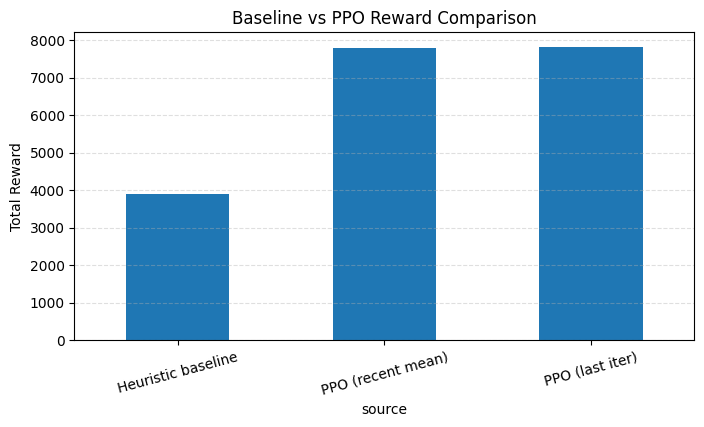

In [5]:
import numpy as np
import pandas as pd
from main import run_episode
from matplotlib import pyplot as plt

BASELINE_EPISODES = 100
baseline_env_config = replace(env_config, flatten_observation=False)
baseline_env = SatelliteMACEnv(config=baseline_env_config)
baseline_rng = np.random.default_rng(seed + 4242)
delta_range = int(baseline_env_config.preamble_delta_range)
baseline_records: list[dict[str, float]] = []

for episode_idx in range(BASELINE_EPISODES):
    episode_seed = int(baseline_rng.integers(0, 1_000_000))
    stats, last_info, _ = run_episode(baseline_env, delta_range, baseline_rng, episode_seed)
    baseline_records.append(
        {
            "episode": episode_idx + 1,
            "steps": stats.steps,
            "total_reward": stats.reward,
            "avg_reward_per_step": stats.reward / max(stats.steps, 1),
            "pending_backoff_cbra": float(last_info.get("pending_backoff_cbra", 0.0)),
            "pending_backoff_pbra": float(last_info.get("pending_backoff_pbra", 0.0)),
        }
    )

baseline_df = pd.DataFrame(baseline_records)
ppo_df = pd.DataFrame(metrics_history) if metrics_history else pd.DataFrame()

baseline_mean_reward = float(baseline_df["avg_reward_per_step"].mean()) if not baseline_df.empty else float("nan")
ppo_recent_mean = float(ppo_df["reward"].tail(5).mean()) if not ppo_df.empty else float("nan")
ppo_last_reward = float(ppo_df["reward"].iloc[-1]) if not ppo_df.empty else float("nan")

comparison_df = pd.DataFrame(
    [
        {"source": "Heuristic baseline", "reward": baseline_mean_reward},
        {"source": "PPO (recent mean)", "reward": ppo_recent_mean},
        {"source": "PPO (last iter)", "reward": ppo_last_reward},
    ]
)

display(baseline_df)
ax = comparison_df.plot(kind="bar", x="source", y="reward", legend=False, figsize=(8, 4))
ax.set_ylabel("Total Reward")
ax.set_title("Baseline vs PPO Reward Comparison")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15)
comparison_df

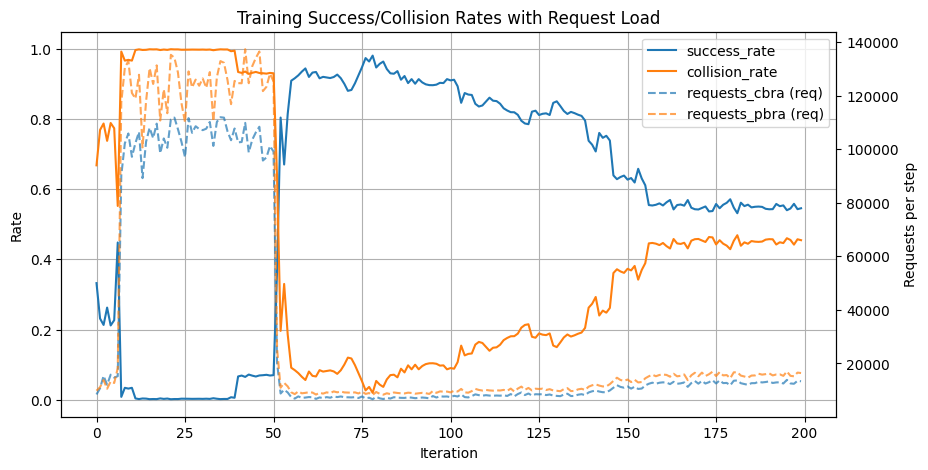

,iteration,success_rate,collision_rate,requests_cbra,requests_pbra
195,195,0.539887,0.460113,13839.514648,16997.097656
196,196,0.544752,0.455248,12518.638672,15349.273438
197,197,0.558065,0.441935,12389.589844,15183.496094
198,198,0.542869,0.457131,13486.106445,16563.171875
199,199,0.545458,0.454542,13326.630859,16393.763672


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

if not metrics_history:
    raise RuntimeError("metrics_history is empty; run the training cell first.")

df = pd.DataFrame(metrics_history)
plot_columns = [col for col in ("success_rate", "collision_rate") if col in df]
request_columns = [col for col in ("requests_cbra", "requests_pbra") if col in df]
if not plot_columns:
    raise RuntimeError("No success_rate/collision_rate columns found in metrics_history.")

fig, ax1 = plt.subplots(figsize=(10, 5))
for column in plot_columns:
    ax1.plot(df["iteration"], df[column], label=column)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Rate")
ax1.set_title("Training Success/Collision Rates with Request Load")
ax1.grid(True)

ax2 = None
if request_columns:
    ax2 = ax1.twinx()
    for column in request_columns:
        ax2.plot(
            df["iteration"],
            df[column],
            linestyle="--",
            label=f"{column} (req)",
            alpha=0.7,
        )
    ax2.set_ylabel("Requests per step")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = (ax2.get_legend_handles_labels() if ax2 else ([], []))
ax1.legend(handles1 + handles2, labels1 + labels2, loc="best")

plt.show()

columns_to_show = ["iteration", *plot_columns, *request_columns]
df[columns_to_show].tail()